This project aims to implement the task of "Text-to-Image Generation."   
By inputting a text description (e.g., "This flower has yellow petals and a black center"), the neural network interprets the semantic meaning of the text and generates a realistic flower image that matches the description.

To present the evolution from fundamental to advanced architectures, this notebook includes both the baseline model and the improved model.   
The overall architecture is divided into the following four sections:

1. Data Preprocessing  
This stage is responsible for converting raw text and image data into tensor formats suitable for the model, ensuring the stability and diversity of the training process.
   - Image Preprocessing:Includes reading images, cropping them into squares, resizing them to the target resolution (e.g., 64x64 or 256x256), applying data augmentation (e.g., random horizontal flipping), and finally normalizing the pixel values to the range of [-1, 1].
   - Text Preprocessing: Tokenizes text descriptions, filters out invalid symbols, and converts them into corresponding integer ID sequences via a dictionary (sent2IdList). Handles sentences of varying lengths through truncation or zero-padding (<PAD>) to ensure consistent input dimensions.
   - Dataset Construction: Utilizes the tf.data.Dataset API to build a highly efficient data pipeline, supporting optimization operations like dynamic batching and multi-threaded prefetching (AUTOTUNE).

2. Model: DC-GAN (Deep Convolutional GAN)   
This stage implements the basic Deep Convolutional Generative Adversarial Network as the baseline model for text-to-image generation.

   - Text Encoder: Uses a Bidirectional LSTM to extract semantic feature vectors from the text.
   - Generator: Concatenates the text feature vector with random normal noise, then progressively upsamples through multiple deconvolutional layers (Conv2DTranspose) to generate an initial 64x64 image.
   - Discriminator: Applies convolutional downsampling to generated or real images, fuses them with text features, and determines whether "the image is real" and whether "the image matches the text description."

3. Model: Stack-GAN (Stacked Generative Adversarial Networks)  
To break through the bottleneck of blurry generation and lack of detail in DC-GAN, this section implements the more advanced Stack-GAN architecture and incorporates an alignment loss (RNN Loss) to enhance the correlation between text and images.

   - RNN Loss & Image Encoder: Introduces Contrastive Loss. Through pre-trained Image and Text Encoders, it maps images and text into the same feature space, significantly improving the model's accuracy in generating corresponding colors.
   - Conditioning Augmentation (CA): Converts the originally fixed text features into a normal distribution and resamples from it. This not only increases the diversity of generated images but, combined with KL Divergence Loss, also creates a smoother latent manifold space.
   1. Stage-I (Low-Resolution Sketch): Focuses on learning the layout and low-frequency features of the image (such as overall shape and base colors), outputting stable 64x64 images.
   2. Stage-II (High-Resolution Refinement): (Optional advanced stage) Freezes Stage-I weights and utilizes Residual Networks (ResNet) to refine high-frequency features and upsample, enlarging the 64x64 sketch to generate a 256x256 high-resolution image with realistic textures.

4. Evaluation & Visualization  
After the model training is complete, this section is responsible for applying the model to an unseen Test Set to verify its generalization ability.

   - Dynamic Inference: Reads text descriptions from the test set, dynamically generates the corresponding amount of random noise, inputs them into the trained Generator to produce predicted images, and automatically saves them to a designated folder.

   - Result Visualization: Randomly samples several test results and uses matplotlib to display the "input text description" side-by-side with the "model-generated image," providing an intuitive demonstration and evaluation of the generation quality and text alignment.

# 0. Setup


In [1]:
import os

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' 
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        tf.config.set_visible_devices(gpus[0], 'GPU')
        print("GPU:", gpus[0])
    except RuntimeError as e:
        print('error:', e)
else:
    print("No GPU found, using CPU instead.")


GPU: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [2]:
from __future__ import absolute_import, division, print_function, unicode_literals
import tensorflow as tf
from tensorflow.keras import layers
import os
import string
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import PIL
import random
import time
from pathlib import Path

import re
from IPython import display


## Preprocess Text

In [3]:
dictionary_path = './dictionary'
vocab = np.load(dictionary_path + '/vocab.npy')
print('there are {} vocabularies in total'.format(len(vocab)))

word2Id_dict = dict(np.load(dictionary_path + '/word2Id.npy'))
id2word_dict = dict(np.load(dictionary_path + '/id2Word.npy'))
print('Word to id mapping, for example: %s -> %s' % ('flower', word2Id_dict['flower']))
print('Id to word mapping, for example: %s -> %s' % ('1', id2word_dict['1']))
print('Tokens: <PAD>: %s; <RARE>: %s' % (word2Id_dict['<PAD>'], word2Id_dict['<RARE>']))

there are 5427 vocabularies in total
Word to id mapping, for example: flower -> 1
Id to word mapping, for example: 1 -> flower
Tokens: <PAD>: 5427; <RARE>: 5428


In [4]:
def sent2IdList(line, MAX_SEQ_LENGTH=20):
    MAX_SEQ_LIMIT = MAX_SEQ_LENGTH
    padding = 0
    
    # data preprocessing, remove all puntuation in the texts
    prep_line = re.sub('[%s]' % re.escape(string.punctuation), ' ', line.rstrip())
    prep_line = prep_line.replace('-', ' ')
    prep_line = prep_line.replace('-', ' ')
    prep_line = prep_line.replace('  ', ' ')
    prep_line = prep_line.replace('.', '')
    tokens = prep_line.split(' ')
    tokens = [
        tokens[i] for i in range(len(tokens))
        if tokens[i] != ' ' and tokens[i] != ''
    ]
    tokens = tokens[:MAX_SEQ_LIMIT]
    
    l = len(tokens)
    padding = MAX_SEQ_LIMIT - l
    
    # make sure length of each text is equal to MAX_SEQ_LENGTH, and replace the less common word with <RARE> token
    for i in range(padding):
        tokens.append('<PAD>')
    line = [
        word2Id_dict[tokens[k]]
        if tokens[k] in word2Id_dict else word2Id_dict['<RARE>']
        for k in range(len(tokens))
    ]

    return line

text = "the flower shown has yellow anther red pistil and bright red petals."
print(text)
print(sent2IdList(text))



the flower shown has yellow anther red pistil and bright red petals.
['9', '1', '82', '5', '11', '70', '20', '31', '3', '29', '20', '2', '5427', '5427', '5427', '5427', '5427', '5427', '5427', '5427']


## Dataset

In [5]:
data_path = './dataset'
df = pd.read_pickle(data_path + '/text2ImgData.pkl')
num_training_sample = len(df)
n_images_train = num_training_sample
print('There are %d image in training data' % (n_images_train))

There are 7370 image in training data


In [6]:
df.head(5)

,Captions,ImagePath
ID,,
6734,"[[9, 2, 17, 9, 1, 6, 14, 13, 18, 3, 41, 8, 11,...",./102flowers/image_06734.jpg
6736,"[[4, 1, 5, 12, 2, 3, 11, 31, 28, 68, 106, 132,...",./102flowers/image_06736.jpg
6737,"[[9, 2, 27, 4, 1, 6, 14, 7, 12, 19, 5427, 5427...",./102flowers/image_06737.jpg
6738,"[[9, 1, 5, 8, 54, 16, 38, 7, 12, 116, 325, 3, ...",./102flowers/image_06738.jpg
6739,"[[4, 12, 1, 5, 29, 11, 19, 7, 26, 70, 5427, 54...",./102flowers/image_06739.jpg


## Create Dataset by Dataset API

In [7]:
# in this competition, you have to generate image in size 64x64x3
IMAGE_HEIGHT = 64
IMAGE_WIDTH = 64
IMAGE_CHANNEL = 3

AUG_NUM = 2 #每張圖片要增量幾張



def training_data_generator(caption, image_path):
    # load in the image according to image path
    img = tf.io.read_file(image_path)
    img = tf.image.decode_image(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = (img - 0.5) * 2.0
    img.set_shape([None, None, 3])
    #置中取短邊裁切
    short = tf.math.minimum(tf.shape(img)[0],tf.shape(img)[1])
    img = tf.image.resize_with_crop_or_pad(img,short,short)
    #影像先+5再隨機裁切、水平垂直隨機翻轉
    img = tf.image.resize(img, size=[IMAGE_HEIGHT+5, IMAGE_WIDTH+5])
    img.set_shape([IMAGE_HEIGHT+5, IMAGE_WIDTH+5, IMAGE_CHANNEL])
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_crop(img,[IMAGE_HEIGHT, IMAGE_WIDTH,IMAGE_CHANNEL])

    caption = tf.cast(caption, tf.int32)

    return img, caption




def dataset_generator(filenames, batch_size, data_generator):
    # load the training data into two NumPy arrays
    df = pd.read_pickle(filenames)
    captions = df['Captions'].values
    caption = []
    # each image has 1 to 10 corresponding captions
    # we choose many of them randomly for training
    #隨機選增量數量的陳述
    for i in range(len(captions)):
        caption.extend(random.choices(captions[i],k=AUG_NUM))
    caption = np.asarray(caption)
    caption = caption.astype(int)

    
    
#以下是一些對Bert的嘗試
    '''
    for i in range(len(caption)):
      for j in range(len(caption[i])):
        if caption[i][j] == 5427:
            caption[i][j] = 0
        else:
            word = id2word_dict[str(caption[i][j])]
            bert_token = tokenizer(word, max_length=1,
                        add_special_tokens=False, truncation=True,
                        padding='max_length', return_tensors="np")
            caption[i][j] = bert_token['input_ids'][0][0]
    '''


    ''' 
    caption_text = []
    for i in range(len(caption)):
        seq = []
        j = 0
        while caption[i][j] != 5427:
            seq.append(id2word_dict[str(caption[i][j])])
            j = j+1
            if j == 20:
                break
        caption_text.append(' '.join(seq))
    caption = np.asarray(caption_text)  

        bert_token = tokenizer(' '.join(seq), max_length=20,
                        add_special_tokens=False, truncation=True,
                        padding='max_length', return_tensors="np")
        caption_text.append(bert_token['input_ids'].reshape(20))

    caption = np.asarray(caption_text)
    '''



    #重複圖片路徑對應增量的數量
    path = df['ImagePath'].values
    image_path = []
    for i in range(len(path)):
        for j in range(AUG_NUM):
            image_path.append(path[i])
    image_path = np.asarray(image_path)
    
    # assume that each row of `features` corresponds to the same row as `labels`.
    assert caption.shape[0] == image_path.shape[0]
    
    dataset = tf.data.Dataset.from_tensor_slices((caption, image_path))
    dataset = dataset.shuffle(len(caption))
    dataset = dataset.map(data_generator, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size, drop_remainder=True)
    dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)

    print(len(caption))
    return dataset


In [8]:
BATCH_SIZE = 64
dataset = dataset_generator(data_path + '/text2ImgData.pkl', BATCH_SIZE, training_data_generator)
#dataset = dataset.take(128)

14740


# 1-1. DC-GAN Model+Train

用CNN對INPUT的圖片做feature extraction

In [9]:
hparas = {
    'MAX_SEQ_LENGTH': 20,                     # maximum sequence length
    'EMBED_DIM': 256,                         # word embedding dimension
    'VOCAB_SIZE': len(word2Id_dict),          # size of dictionary of captions
    'RNN_HIDDEN_SIZE': 128,                   # number of RNN neurons
    'Z_DIM': 512,                             # random noise z dimension
    'DENSE_DIM': 128,                         # number of neurons in dense layer
    'IMAGE_SIZE': [64, 64, 3],                # render image size
    'BATCH_SIZE': 64,
    'LR': 2e-4,
    'LR_DECAY': 0.5,
    'BETA_1': 0.5,
    'N_EPOCH': 100,
    'N_SAMPLE': num_training_sample,          # size of training data
    'CHECKPOINTS_DIR': './checkpoints/demo',  # checkpoint path
    'PRINT_FREQ': 1                           # printing frequency of loss
}

In [10]:
class ImageEncoder(tf.keras.Model):

    def __init__(self, hparas):
        super(ImageEncoder, self).__init__()
        self.hparas = hparas
        self.flatten = tf.keras.layers.Flatten()
        self.d_img = tf.keras.layers.Dense(self.hparas['DENSE_DIM']*2)

        def conv_bn_lrelu(out_dim):
            return tf.keras.Sequential([
                tf.keras.layers.Conv2D(out_dim, kernel_size = 4, strides = 2, padding = "SAME"),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.LeakyReLU(alpha = 0.2),
            ])

        self.ls = tf.keras.Sequential([
            conv_bn_lrelu(self.hparas['DENSE_DIM'] * 1),
            conv_bn_lrelu(self.hparas['DENSE_DIM'] * 2),
            conv_bn_lrelu(self.hparas['DENSE_DIM'] * 4),
            conv_bn_lrelu(self.hparas['DENSE_DIM'] * 8),          
        ])
    
    def call(self, img, training=False):

        img = self.ls(img, training=training)
        img = self.flatten(img)
        img = self.d_img(img)
        img_embed = tf.math.l2_normalize(img, axis=1)
        
        return img_embed

用RNN做textencoder提取文字特徵，嘗試過gru, lstm,

In [11]:
class TextEncoder(tf.keras.Model):
    """
    Encode text (a caption) into hidden representation
    input: text, which is a list of ids
    output: embedding, or hidden representation of input text in dimension of RNN_HIDDEN_SIZE
    """
    def __init__(self, hparas):
        super(TextEncoder, self).__init__()
        self.hparas = hparas
        self.batch_size = self.hparas['BATCH_SIZE']
        
        # embedding with tensorflow API
        self.embedding = layers.Embedding(self.hparas['VOCAB_SIZE'], self.hparas['EMBED_DIM'])
        # RNN, here we use GRU cell, another common RNN cell similar to LSTM
        self.gru = layers.GRU(self.hparas['RNN_HIDDEN_SIZE'],
                              return_sequences=True,
                              return_state=True,
                              recurrent_initializer='glorot_uniform')
        self.lstm = layers.LSTM(self.hparas['RNN_HIDDEN_SIZE'],
                              return_sequences=True,
                              return_state=True,
                              recurrent_initializer='glorot_uniform')
        self.rnn = tf.keras.layers.Bidirectional(
                        tf.keras.layers.LSTM(units=self.hparas['RNN_HIDDEN_SIZE'], 
                                             return_sequences=True, 
                                             return_state=True)
                   )
        # if self.bidirectional:
        #     self.rnn = tf.keras.layers.Bidirectional(self.rnn)
        """
        if also return_state=True, 
        whole_sequence, forward_hidden, forward_cell, backward_hidden, backward_cell (LSTM)
        whole_sequence, forward_hidden, forward_cell (GRU)
        sent_emb = tf.concat([forward_hidden, backward_hidden], axis=-1)
        """
    
    def call(self, text, hidden):
        text = self.embedding(text)
        # output, state = self.gru(text, initial_state = hidden)

        # output, state_h, state_c = self.lstm(text, initial_state = hidden)
        # state = [state_h, state_c]

        # output, state = self.rnn_layer(text, initial_state = hidden)
        # output, state = self.rnn_layer(text, hidden)

        output, forward_h, forward_c, backward_h, backward_c = self.rnn(text, initial_state = hidden)
        state_h = tf.concat([forward_h, backward_h], axis=-1)
        state_c = tf.concat([forward_c, backward_c], axis=-1)
        state = [state_h, state_c]

        text_embed = tf.math.l2_normalize(state_h, axis=1)

        return text_embed, state
    
    def initialize_hidden_state(self):
        # return tf.zeros((self.hparas['BATCH_SIZE'], self.hparas['RNN_HIDDEN_SIZE']))
        # return [tf.zeros((self.hparas['BATCH_SIZE'], self.hparas['RNN_HIDDEN_SIZE'])), tf.zeros((self.hparas['BATCH_SIZE'], self.hparas['RNN_HIDDEN_SIZE']))]
        
        return [tf.zeros((self.hparas['BATCH_SIZE'], self.hparas['RNN_HIDDEN_SIZE'])) for i in range(4)]

用多層conv,deconv的dcgan訓練

In [12]:
class Generator(tf.keras.Model):
    """
    Generate fake image based on given text(hidden representation) and noise z
    input: text and noise
    output: fake image with size 64*64*3
    """
    def __init__(self, hparas):
        super(Generator, self).__init__()
        self.hparas = hparas
        self.flatten = tf.keras.layers.Flatten()
        self.d1 = tf.keras.layers.Dense(self.hparas['DENSE_DIM'])
        self.d2 = tf.keras.layers.Dense(64*64*3)

        def dconv_bn_relu(out_dim):
            return tf.keras.Sequential([
                tf.keras.layers.Conv2DTranspose(out_dim, kernel_size = 5, strides = 2, padding = "SAME", use_bias=False),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.ReLU(),
            ])
        self.l1 = tf.keras.Sequential([
            tf.keras.layers.Dense(self.hparas['DENSE_DIM'] * 8 * 4 * 4, use_bias=False),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.ReLU(),
        ])
        self.l2_5 = tf.keras.Sequential([
            dconv_bn_relu(self.hparas['DENSE_DIM'] * 4),
            dconv_bn_relu(self.hparas['DENSE_DIM'] * 2),
            dconv_bn_relu(self.hparas['DENSE_DIM'] * 1),
            tf.keras.layers.Conv2DTranspose(3, kernel_size = 4, strides = 2, padding = "SAME"),
            # nn.Tanh()
        ]) 
        
    def call(self, text, noise_z, training=False):
        text = self.flatten(text)
        text = self.d1(text)
        text = tf.nn.leaky_relu(text)
        
        # concatenate input text and random noise
        text_concat = tf.concat([noise_z, text], axis=1)
        # text_concat = self.d2(text_concat)

        x = self.l1(text_concat, training=training)
        x = tf.reshape(x, [-1, 4, 4, 128 * 8])
        x = self.l2_5(x, training=training)

        logits = tf.reshape(x, [-1, 64, 64, 3])
        output = tf.nn.tanh(logits)
        
        return logits, output

In [13]:
class Discriminator(tf.keras.Model):
    """
    Differentiate the real and fake image using Spatial Replication
    input: image and corresponding text
    output: labels, the real image should be 1, while the fake should be 0
    """
    def __init__(self, hparas):
        super(Discriminator, self).__init__()
        self.hparas = hparas
        self.flatten = tf.keras.layers.Flatten()
        
        # 將文字特徵壓縮/轉換到特定維度
        self.d_text = tf.keras.layers.Dense(self.hparas['DENSE_DIM'])
        
        # 影像特徵萃取 (Downsampling)
        def conv_bn_lrelu(out_dim):
            return tf.keras.Sequential([
                tf.keras.layers.Conv2D(out_dim, kernel_size=5, strides=2, padding="SAME"),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.LeakyReLU(negative_slope=0.2), # 修正了舊版 alpha 參數的棄用警告
            ])

        self.ls = tf.keras.Sequential([
            # 64x64x3 -> 32x32xDENSE_DIM
            tf.keras.layers.Conv2D(self.hparas['DENSE_DIM'], kernel_size=5, strides=2, padding="SAME"), 
            tf.keras.layers.LeakyReLU(negative_slope=0.2),
            # 32x32 -> 16x16
            conv_bn_lrelu(self.hparas['DENSE_DIM'] * 2),
            # 16x16 -> 8x8
            conv_bn_lrelu(self.hparas['DENSE_DIM'] * 4),
            # 8x8 -> 4x4
            conv_bn_lrelu(self.hparas['DENSE_DIM'] * 8),          
        ])
        
        # 融合後的 1x1 卷積層，用來學習空間上的圖文交互特徵
        self.fusion_conv = tf.keras.Sequential([
            tf.keras.layers.Conv2D(self.hparas['DENSE_DIM'] * 8, kernel_size=1, strides=1, padding="SAME"),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.LeakyReLU(negative_slope=0.2),
        ])

        # 最後輸出一維的機率值
        self.d = tf.keras.layers.Dense(1)
    
    def call(self, img, text, training=False):
        # 1. 處理文字特徵
        text = self.flatten(text)
        text = self.d_text(text)
        text = tf.nn.leaky_relu(text, alpha=0.2)
        
        # 擴增維度以配合 Spatial Replication: [batch, 128] -> [batch, 1, 1, 128]
        text_expanded = tf.expand_dims(tf.expand_dims(text, 1), 1)
        # 複製成 4x4 的空間大小: [batch, 4, 4, 128]
        text_tiled = tf.tile(text_expanded, [1, 4, 4, 1])

        # 2. 處理影像特徵
        # 輸出維度: [batch, 4, 4, DENSE_DIM * 8] (假設 DENSE_DIM=128，這裡就是 1024)
        img_features = self.ls(img, training=training)
        
        # 3. 在 Channel 維度上進行拼接 (Concatenate)
        # 結果維度: [batch, 4, 4, 1024 + 128] = [batch, 4, 4, 1152]
        img_text_concat = tf.concat([img_features, text_tiled], axis=-1)
        
        # 4. 融合特徵並輸出
        fusion_features = self.fusion_conv(img_text_concat, training=training)
        flatten_features = self.flatten(fusion_features)
        
        logits = self.d(flatten_features)
        output = tf.nn.sigmoid(logits)
        
        return logits, output

In [14]:
image_encoder = ImageEncoder(hparas)
text_encoder = TextEncoder(hparas)
generator = Generator(hparas)
discriminator = Discriminator(hparas)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


另外加上兩種loss，分別是正確圖片加上錯誤caption，和錯誤圖片加上正確caption，使GAN產生更真實的圖片


In [15]:
# This method returns a helper function to compute cross entropy loss
# cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)
# cross_entropy = tf.nn.sigmoid_cross_entropy_with_logits()

def discriminator_loss(real_logits, fake_logits, wrong_logits):
    # output value of real image should be 1
    # real_loss = cross_entropy(tf.ones_like(real_logits)*0.9, real_logits)
    real_loss = tf.reduce_mean(tf.nn.sigmoid_cross_entropy_with_logits(labels=tf.ones_like(real_logits)*0.9, logits=real_logits))
    # output value of fake image should be 0
    # fake_loss = cross_entropy(tf.zeros_like(fake_logits)+0.1, fake_logits)
    fake_loss = tf.reduce_mean(tf.nn.sigmoid_cross_entropy_with_logits(labels=tf.zeros_like(fake_logits)+0.1, logits=fake_logits))

    # wrong_loss = cross_entropy(tf.zeros_like(wrong_logits)+0.1, wrong_logits)
    wrong_loss = tf.reduce_mean(tf.nn.sigmoid_cross_entropy_with_logits(labels=tf.zeros_like(wrong_logits)+0.1, logits=wrong_logits))

    total_loss = real_loss + (fake_loss + wrong_loss)/2
    return total_loss

    # return tf.reduce_mean(fake_logits) - tf.reduce_mean(real_logits)


def generator_loss(fake_output):
    # output value of fake image should be 0
    # return cross_entropy(tf.ones_like(fake_output)*0.9, fake_output)

    return tf.reduce_mean(tf.nn.sigmoid_cross_entropy_with_logits(labels=tf.ones_like(fake_output)*0.9, logits=fake_output))

    # return -tf.reduce_mean(fake_output)

In [16]:
# 1. 計算衰減的步數 (Decay Steps)
# 假設我們希望每 25 個 Epoch 讓學習率衰減一半
steps_per_epoch = int(hparas['N_SAMPLE'] / hparas['BATCH_SIZE'])
decay_epochs = 25
decay_steps = steps_per_epoch * decay_epochs

# 2. 為 Generator 與 Discriminator 設定學習率排程器 (起始 1e-4)
lr_schedule_gan = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=1e-4,
    decay_steps=decay_steps,
    decay_rate=hparas['LR_DECAY'], # 這裡會吃到你設定的 0.5
    staircase=True # True 代表以階梯式下降 (每 25 epoch 砍半一次)，False 則是平滑連續下降
)

# 3. 為 RNN Encoders 設定學習率排程器 (起始 2e-4)
lr_schedule_rnn = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=hparas['LR'],
    decay_steps=decay_steps,
    decay_rate=hparas['LR_DECAY'],
    staircase=True
)

# 4. 宣告帶有 Decay 排程器的 Optimizers
rnn_optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule_rnn, beta_1=hparas['BETA_1'])
generator_optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule_gan, beta_1=hparas['BETA_1'])
discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule_gan, beta_1=hparas['BETA_1'])

In [17]:
# one benefit of tf.train.Checkpoint() API is we can save everything seperately
checkpoint_dir = hparas['CHECKPOINTS_DIR']
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")
checkpoint = tf.train.Checkpoint(text_encoder=text_encoder,
                                 generator=generator,
                                 discriminator=discriminator
                                 )

使用cosine_similarity計算rnn loss

In [18]:
def cosine_similarity(v1, v2):
    cost = tf.reduce_sum(tf.multiply(v1, v2), 1) / (tf.sqrt(tf.reduce_sum(tf.multiply(v1, v1), 1)) * tf.sqrt(tf.reduce_sum(tf.multiply(v2, v2), 1)) + 1e-8)
    return cost

In [19]:
@tf.function
def train_step(real_image, caption, hidden):
    # random noise for generator
    noise = tf.random.normal(shape=[hparas['BATCH_SIZE'], hparas['Z_DIM']], mean=0.0, stddev=1.0)
    current_batch_size = tf.shape(real_image)[0]
    #noise = tf.random.normal([current_batch_size, 512])
    with tf.GradientTape() as rnn_tape, tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:

        x = image_encoder(real_image, training = True)
        v, _ = text_encoder(caption, hidden, training = True)
        #x_w = image_encoder(tf.random.shuffle(real_image), training = True)
        #v_w, _ = text_encoder(tf.random.shuffle(caption), hidden, training = True)
        x_w = tf.random.shuffle(x) 
        v_w = tf.random.shuffle(v)

        alpha = 0.2 # margin alpha

        sim_pos = tf.reduce_sum(x * v, axis=1)
        sim_neg_img = tf.reduce_sum(x * v_w, axis=1)
        sim_neg_txt = tf.reduce_sum(x_w * v, axis=1)
        rnn_loss = tf.reduce_mean(tf.maximum(0., alpha - sim_pos + sim_neg_img)) + \
                   tf.reduce_mean(tf.maximum(0., alpha - sim_pos + sim_neg_txt))


        #text_embed, hidden = text_encoder(caption, hidden, training = True)
        text_embed = v
        _, fake_image = generator(text_embed, noise, training = True)
        real_logits, real_output = discriminator(real_image, text_embed, training = True)
        fake_logits, fake_output = discriminator(fake_image, text_embed, training = True)

        # wrong_logits, wrong_output = discriminator(tf.random.shuffle(real_image), text_embed)
        wrong_logits, wrong_output = discriminator(real_image, v_w, training = True)

        g_loss = generator_loss(fake_logits)
        d_loss = discriminator_loss(real_logits, fake_logits, wrong_logits)

    grad_rnn, _ = tf.clip_by_global_norm(rnn_tape.gradient(rnn_loss, image_encoder.trainable_variables + text_encoder.trainable_variables), 10)
    grad_g = gen_tape.gradient(g_loss, generator.trainable_variables)
    grad_d = disc_tape.gradient(d_loss, discriminator.trainable_variables)

    rnn_optimizer.apply_gradients(zip(grad_rnn, image_encoder.trainable_variables + text_encoder.trainable_variables))
    generator_optimizer.apply_gradients(zip(grad_g, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(grad_d, discriminator.trainable_variables))

    # clipping
    # for v in discriminator.trainable_variables: 
    #     v.assign(tf.clip_by_value(v, -0.01, 0.01))
    
    return rnn_loss, g_loss, d_loss

In [20]:
@tf.function
def test_step(caption, noise, hidden):
    text_embed, hidden = text_encoder(caption, hidden, training = False)
    _, fake_image = generator(text_embed, noise, training = False)
    return fake_image   

In [21]:
def merge(images, size):
    h, w = images.shape[1], images.shape[2]
    img = np.zeros((h * size[0], w * size[1], 3))
    for idx, image in enumerate(images):
        i = idx % size[1]
        j = idx // size[1]
        img[j*h:j*h+h, i*w:i*w+w, :] = image
    return img

def imsave(images, size, path):
    # getting the pixel values between [0, 1] to save it
    return plt.imsave(path, merge(images, size)*0.5 + 0.5)

def save_images(images, size, image_path):
    return imsave(images, size, image_path)

def sample_generator(caption, batch_size):
    caption = np.asarray(caption)
    caption = caption.astype(int)
    dataset = tf.data.Dataset.from_tensor_slices(caption)
    dataset = dataset.batch(batch_size)
    return dataset  


ni = int(np.ceil(np.sqrt(hparas['BATCH_SIZE'])))
sample_size = hparas['BATCH_SIZE']
sample_seed = np.random.normal(loc=0.0, scale=1.0, size=(sample_size, hparas['Z_DIM'])).astype(np.float32)
sample_sentence = ["the flower shown has yellow anther red pistil and bright red petals."] * int(sample_size/ni) + \
                  ["this flower has petals that are yellow, white and purple and has dark lines"] * int(sample_size/ni) + \
                  ["the petals on this flower are white with a yellow center"] * int(sample_size/ni) + \
                  ["this flower has a lot of small round pink petals."] * int(sample_size/ni) + \
                  ["this flower is orange in color, and has petals that are ruffled and rounded."] * int(sample_size/ni) + \
                  ["the flower has yellow petals and the center of it is brown."] * int(sample_size/ni) + \
                  ["this flower has petals that are blue and white."] * int(sample_size/ni) +\
                  ["these white flowers have petals that start off white in color and end in a white towards the tips."] * int(sample_size/ni)

for i, sent in enumerate(sample_sentence):
    sample_sentence[i] = sent2IdList(sent)
sample_sentence = sample_generator(sample_sentence, hparas['BATCH_SIZE'])      

In [22]:
if not os.path.exists('samples/demo'):
    os.makedirs('samples/demo')

def train(dataset, epochs):
    # hidden state of RNN
    hidden = text_encoder.initialize_hidden_state()
    steps_per_epoch = int(hparas['N_SAMPLE']/hparas['BATCH_SIZE'])
    
    for epoch in range(hparas['N_EPOCH']):
        rnn_total_loss = 0
        g_total_loss = 0
        d_total_loss = 0
        start = time.time()
        
        for image, caption in dataset:
            rnn_loss, g_loss, d_loss = train_step(image, caption, hidden)
            rnn_total_loss += rnn_loss.numpy()
            g_total_loss += g_loss.numpy()
            d_total_loss += d_loss.numpy()
            
        time_tuple = time.localtime()
        time_string = time.strftime("%m/%d/%Y, %H:%M:%S", time_tuple)
            
        print("Epoch {}, rnn_loss: {:.6f}, gen_loss: {:.6f}, disc_loss: {:.6f}".format(epoch+1,
                                                                                       rnn_total_loss/steps_per_epoch,
                                                                                       g_total_loss/steps_per_epoch,
                                                                                       d_total_loss/steps_per_epoch))
        print('Time for epoch {} is {:.4f} sec'.format(epoch+1, time.time()-start))
        
        # save the model
        if (epoch + 1) % 50 == 0:
            checkpoint.save(file_prefix = checkpoint_prefix)
        
        # visualization
        if (epoch + 1) % hparas['PRINT_FREQ'] == 0:
            for caption in sample_sentence:
                fake_image = test_step(caption, sample_seed, hidden)
            save_images(fake_image, [ni, ni], 'samples/dc_gan_demo/train_{:02d}.jpg'.format(epoch))


In [24]:
train(dataset, hparas['N_EPOCH'])

Epoch 1, rnn_loss: 0.742261, gen_loss: 3.303442, disc_loss: 2.378688
Time for epoch 1 is 32.8220 sec
Epoch 2, rnn_loss: 0.513732, gen_loss: 3.208014, disc_loss: 1.849408
Time for epoch 2 is 32.1038 sec
Epoch 3, rnn_loss: 0.496816, gen_loss: 3.437390, disc_loss: 1.705344
Time for epoch 3 is 32.4522 sec
Epoch 4, rnn_loss: 0.494841, gen_loss: 2.898453, disc_loss: 1.814543
Time for epoch 4 is 32.0266 sec
Epoch 5, rnn_loss: 0.485374, gen_loss: 2.813386, disc_loss: 1.840256
Time for epoch 5 is 32.1153 sec
Epoch 6, rnn_loss: 0.470664, gen_loss: 3.003415, disc_loss: 1.781169
Time for epoch 6 is 31.9495 sec
Epoch 7, rnn_loss: 0.440870, gen_loss: 2.928030, disc_loss: 1.775017
Time for epoch 7 is 32.2227 sec
Epoch 8, rnn_loss: 0.430692, gen_loss: 2.794762, disc_loss: 1.807378
Time for epoch 8 is 32.7528 sec
Epoch 9, rnn_loss: 0.416343, gen_loss: 2.705610, disc_loss: 1.804908
Time for epoch 9 is 31.9555 sec
Epoch 10, rnn_loss: 0.404005, gen_loss: 2.684669, disc_loss: 1.806578
Time for epoch 10 is 

# 1-2. Stack GAN Model+Train

In [44]:
hparas = {
    'MAX_SEQ_LENGTH': 20,                     # maximum sequence length
    'EMBED_DIM': 256,                         # word embedding dimension
    'VOCAB_SIZE': len(word2Id_dict),          # size of dictionary of captions
    'RNN_HIDDEN_SIZE': 128,                   # number of RNN neurons
    'Z_DIM': 512,                             # random noise z dimension
    'DENSE_DIM': 128,                         # number of neurons in dense layer
    'IMAGE_SIZE': [64, 64, 3],                # render image size
    'BATCH_SIZE': 64,
    'LR': 2e-4,
    'LR_SIZE': 64,
    'LR_DECAY': 0.5,
    'BETA_1': 0.5,                             # AdamOptimizer parameter
    'N_EPOCH': 100,
    'DECAY_EVERY':100,
    'N_SAMPLE': num_training_sample,          # size of training data
    'CHECKPOINTS_DIR': './checkpoints/demo2',  # checkpoint path
    'PRINT_FREQ': 'samples/demo/',
    'PRINT_FREQ': 1                           # printing frequency of loss
}

In [45]:
class ImageEncoder(tf.keras.Model):
    def __init__(self, hparas):
        super(ImageEncoder, self).__init__()
        self.hparas = hparas
        self.flatten = tf.keras.layers.Flatten()
        
        self.d_img = tf.keras.layers.Dense(self.hparas['RNN_HIDDEN_SIZE'] * 2)

        def conv_bn_lrelu(out_dim):
            return tf.keras.Sequential([
                tf.keras.layers.Conv2D(out_dim, kernel_size=4, strides=2, padding="SAME"),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.LeakyReLU(alpha=0.2),
            ])

        self.ls = tf.keras.Sequential([
            conv_bn_lrelu(self.hparas['DENSE_DIM'] * 1),
            conv_bn_lrelu(self.hparas['DENSE_DIM'] * 2),
            conv_bn_lrelu(self.hparas['DENSE_DIM'] * 4),
            conv_bn_lrelu(self.hparas['DENSE_DIM'] * 8),          
        ])
    
    def call(self, img, training=False):
        img = self.ls(img, training=training)
        img = self.flatten(img)
        img = self.d_img(img)
        img_embed = tf.math.l2_normalize(img, axis=1)
        
        return img_embed

In [46]:
class TextEncoder(tf.keras.Model):
    """
    Encode text (a caption) into hidden representation
    input: text, which is a list of ids
    output: embedding, or hidden representation of input text in dimension of RNN_HIDDEN_SIZE
    """
    def __init__(self, hparas):
        super(TextEncoder, self).__init__()
        self.hparas = hparas
        self.batch_size = self.hparas['BATCH_SIZE']
        
        # embedding with tensorflow API
        self.embedding = layers.Embedding(self.hparas['VOCAB_SIZE'], self.hparas['EMBED_DIM'])
        # RNN, here we use GRU cell, another common RNN cell similar to LSTM
        self.gru = layers.GRU(self.hparas['RNN_HIDDEN_SIZE'],
                              return_sequences=True,
                              return_state=True,
                              recurrent_initializer='glorot_uniform')
        self.lstm = layers.LSTM(self.hparas['RNN_HIDDEN_SIZE'],
                              return_sequences=True,
                              return_state=True,
                              recurrent_initializer='glorot_uniform')
        self.rnn = tf.keras.layers.Bidirectional(
                        tf.keras.layers.LSTM(units=self.hparas['RNN_HIDDEN_SIZE'], 
                                             return_sequences=True, 
                                             return_state=True)
                   )
        # if self.bidirectional:
        #     self.rnn = tf.keras.layers.Bidirectional(self.rnn)
        """
        if also return_state=True, 
        whole_sequence, forward_hidden, forward_cell, backward_hidden, backward_cell (LSTM)
        whole_sequence, forward_hidden, forward_cell (GRU)
        sent_emb = tf.concat([forward_hidden, backward_hidden], axis=-1)
        """
    
    def call(self, text, hidden):
        text = self.embedding(text)
        # output, state = self.gru(text, initial_state = hidden)

        # output, state_h, state_c = self.lstm(text, initial_state = hidden)
        # state = [state_h, state_c]

        # output, state = self.rnn_layer(text, initial_state = hidden)
        # output, state = self.rnn_layer(text, hidden)

        output, forward_h, forward_c, backward_h, backward_c = self.rnn(text, initial_state = hidden)
        state_h = tf.concat([forward_h, backward_h], axis=-1)
        state_c = tf.concat([forward_c, backward_c], axis=-1)
        state = [state_h, state_c]

        text_embed = tf.math.l2_normalize(state_h, axis=1)

        return text_embed, state
    
    def initialize_hidden_state(self):
        # return tf.zeros((self.hparas['BATCH_SIZE'], self.hparas['RNN_HIDDEN_SIZE']))
        # return [tf.zeros((self.hparas['BATCH_SIZE'], self.hparas['RNN_HIDDEN_SIZE'])), tf.zeros((self.hparas['BATCH_SIZE'], self.hparas['RNN_HIDDEN_SIZE']))]
        
        return [tf.zeros((self.hparas['BATCH_SIZE'], self.hparas['RNN_HIDDEN_SIZE'])) for i in range(4)]

In [76]:
#Stage-I GAN Generator
class Generator(tf.keras.Model):
    """
    Generate fake image based on given text(hidden representation) and noise z
    input: text and noise
    output: fake image with size 64*64*3
    """
    def __init__(self, hparas_g):
        super(Generator, self).__init__()
        
        self.hparas = hparas_g

        self.gf_dim = 128
        self.s2, self.s4 = self.hparas['LR_SIZE'] // 2, self.hparas['LR_SIZE'] // 4
        self.s8, self.s16 = self.hparas['LR_SIZE'] // 8, self.hparas['LR_SIZE'] // 16
        self.fc_initializer = tf.random_normal_initializer(0, 0.02)
        self.deconv2d_initializer = tf.random_normal_initializer(0, 0.02)
        self.gamma_initializer = tf.random_normal_initializer(1, 0.02)
        
        self.d1 = tf.keras.layers.Dense(self.hparas['RNN_HIDDEN_SIZE'] * 2, activation=tf.nn.leaky_relu, 
                                     kernel_initializer=self.fc_initializer)
        self.d2 = tf.keras.layers.Dense(self.s16 * self.s16 * self.gf_dim * 8, 
                                    kernel_initializer=self.fc_initializer)
        
        self.W1  = tf.compat.v1.get_variable("weights1", shape=[4, 4, self.gf_dim * 4, self.gf_dim * 8],
                                 initializer=self.deconv2d_initializer,trainable=True)
        
        self.W2  = tf.compat.v1.get_variable("weights2", shape=[4, 4, self.gf_dim * 2, self.gf_dim * 4],
                                 initializer=self.deconv2d_initializer,trainable=True)
        
        self.W3 = tf.compat.v1.get_variable("weights3", shape=[4, 4, self.gf_dim, self.gf_dim * 2],
                                 initializer=self.deconv2d_initializer,trainable=True)
        
        self.W4 = tf.compat.v1.get_variable("weights4", shape=[4, 4, 3, self.gf_dim],
                                 initializer=self.deconv2d_initializer,trainable=True)
        self.bn0 = tf.keras.layers.BatchNormalization(momentum=0.9, epsilon=1e-5, gamma_initializer=self.gamma_initializer)
        self.bn1 = tf.keras.layers.BatchNormalization(momentum=0.9, epsilon=1e-5, gamma_initializer=self.gamma_initializer)
        self.bn2 = tf.keras.layers.BatchNormalization(momentum=0.9, epsilon=1e-5, gamma_initializer=self.gamma_initializer)
        self.bn3 = tf.keras.layers.BatchNormalization(momentum=0.9, epsilon=1e-5, gamma_initializer=self.gamma_initializer)
   
   
    def _deconv_bn_relu(self, inputs, W, out_shape, bn_layer, training):
        node = tf.nn.conv2d_transpose(inputs, W, output_shape=out_shape, strides=[1,2,2,1], padding='SAME')
        node = bn_layer(node, training=training)
        node = tf.nn.relu(node)
        return node
    
    def call(self, text, noise_z, training=False):
        """
        Conditioning Augmentation
        """
        conditions = self.d1(text)
        mean = conditions[:, :self.hparas['RNN_HIDDEN_SIZE']]
        log_sigma = conditions[:, self.hparas['RNN_HIDDEN_SIZE']:]
        epsilon = tf.compat.v1.truncated_normal(tf.shape(mean))
        stddev = tf.exp(log_sigma)
        c = mean + stddev * epsilon
        KLloss = -log_sigma + 0.5 * (-1 + tf.exp(2. * log_sigma) + tf.square(mean)) #KL Divergence
        KLloss = tf.reduce_mean(KLloss)
        
        #self.kloss = KLloss
        
        """
        Stage-I Generator G0 for sketch
        """
        z_text_concat = tf.concat([c, noise_z], axis=1)
        g_net = self.d2(z_text_concat)
        """
        Upsampling
        """
        g_net = tf.reshape(g_net, [-1, self.s16, self.s16, self.gf_dim * 8])
        g_net = self.bn0(g_net, training=training)
        g_net = tf.nn.relu(g_net)

        curr_batch_size = tf.shape(text)[0]

        # 將原本的 self.hparas['BATCH_SIZE'] 全面替換成 curr_batch_size
        g_net = self._deconv_bn_relu(g_net, self.W1, [curr_batch_size, self.s8, self.s8, self.gf_dim * 4], self.bn1, training)
        g_net = self._deconv_bn_relu(g_net, self.W2, [curr_batch_size, self.s4, self.s4, self.gf_dim * 2], self.bn2, training)
        g_net = self._deconv_bn_relu(g_net, self.W3, [curr_batch_size, self.s2, self.s2, self.gf_dim], self.bn3, training)

        g_net = tf.nn.conv2d_transpose(g_net, self.W4, output_shape=[curr_batch_size,
                                                                     self.hparas['LR_SIZE'],
                                                                     self.hparas['LR_SIZE'], 3], 
                                       strides=[1,2,2,1], padding='SAME')
        
        output = tf.nn.tanh(g_net)
        return g_net, output, KLloss

In [48]:
#Stage-I GAN Discriminator
class Discriminator(tf.keras.Model):
    def __init__(self, hparas):
        super(Discriminator, self).__init__()
        self.hparas = hparas
        self.df_dim = 64
        self.s2, self.s4 = self.hparas['LR_SIZE'] // 2, self.hparas['LR_SIZE'] // 4
        self.s8, self.s16 = self.hparas['LR_SIZE'] // 8, self.hparas['LR_SIZE'] // 16
        self.fc_initializer = tf.random_normal_initializer(0, 0.02)
        self.conv2d_initializer = tf.compat.v1.truncated_normal_initializer(0, 0.02)
        self.gamma_initializer = tf.random_normal_initializer(1, 0.02)
        self.d1 = tf.keras.layers.Dense(self.hparas['RNN_HIDDEN_SIZE'], activation=tf.keras.layers.LeakyReLU(),
                                          kernel_initializer=self.fc_initializer)
        self.cv1 = tf.keras.layers.Conv2D(self.df_dim , kernel_size=[4, 4], strides=[2, 2],
                                            padding='SAME', activation=tf.nn.leaky_relu, 
                                            use_bias=False, kernel_initializer=self.conv2d_initializer)
        
        self.cv2 = tf.keras.layers.Conv2D(self.df_dim * 2, kernel_size= [4, 4], strides=[2, 2],padding='same',
                                      use_bias=False, kernel_initializer=self.conv2d_initializer)
        
        self.cv3 = tf.keras.layers.Conv2D(self.df_dim * 4, kernel_size= [4, 4], strides=[2, 2],padding='same',
                                      use_bias=False, kernel_initializer=self.conv2d_initializer)
        
        self.cv4 = tf.keras.layers.Conv2D(self.df_dim * 8, kernel_size= [4, 4], strides=[2, 2],padding='same',
                                      use_bias=False, kernel_initializer=self.conv2d_initializer)
        
        self.cv5 = tf.keras.layers.Conv2D(self.df_dim * 8, kernel_size= [1, 1], strides=[1, 1],padding='same',
                                      use_bias=False, kernel_initializer=self.conv2d_initializer)
        
        self.cv6 = tf.keras.layers.Conv2D(1, kernel_size=[self.s16, self.s16], strides=[self.s16, self.s16],padding='SAME',
                                                   use_bias=False, kernel_initializer=self.conv2d_initializer)
        self.bn_cv2 = tf.keras.layers.BatchNormalization(momentum=0.9, epsilon=1e-5, gamma_initializer=self.gamma_initializer)
        self.bn_cv3 = tf.keras.layers.BatchNormalization(momentum=0.9, epsilon=1e-5, gamma_initializer=self.gamma_initializer)
        self.bn_cv4 = tf.keras.layers.BatchNormalization(momentum=0.9, epsilon=1e-5, gamma_initializer=self.gamma_initializer)
        self.bn_cv5 = tf.keras.layers.BatchNormalization(momentum=0.9, epsilon=1e-5, gamma_initializer=self.gamma_initializer)
    
    def call(self, img, text, training=False):
        text_decode = self.d1(text)
        text_decode = tf.expand_dims(tf.expand_dims(text_decode, 1), 1)
        text_decode = tf.tile(text_decode, [1, self.s16, self.s16, 1])
        """
        Downsampling
        """
        image_decode = self.cv1(img)

        image_decode = self.cv2(image_decode)
        image_decode = self.bn_cv2(image_decode, training=training)
        image_decode = tf.nn.leaky_relu(image_decode)

        image_decode = self.cv3(image_decode)
        image_decode = self.bn_cv3(image_decode, training=training)
        image_decode = tf.nn.leaky_relu(image_decode)

        image_decode = self.cv4(image_decode)
        image_decode = self.bn_cv4(image_decode, training=training)
        image_decode = tf.nn.leaky_relu(image_decode)

        """
        Compression and Spatial Replication
        """
        
        concat_decode = tf.concat([image_decode, text_decode], axis=3)

        concat_decode = self.cv5(concat_decode)
        concat_decode  = self.bn_cv5(concat_decode, training=training)
        concat_decode = tf.nn.leaky_relu(concat_decode )


        concat_decode = self.cv6(concat_decode)
        # 攤平為 2D Tensor
        logits = tf.keras.layers.Flatten()(concat_decode) 
        output = tf.nn.sigmoid(logits)

        
        return logits,output

In [49]:
text_encoder = TextEncoder(hparas)
generator = Generator(hparas)
discriminator = Discriminator(hparas)
image_encoder = ImageEncoder(hparas)

將output進行sigmoid運算，再算cross entropy

In [50]:
def cross_entropy(label,logit):
    return tf.reduce_mean(tf.nn.sigmoid_cross_entropy_with_logits(logits=logit,labels=label))

In [51]:
#Discrimnator的loss需考慮真正的圖，Generator產生的圖和亂序真實的圖的辨識loss

def discriminator_loss(real_logits, fake_logits,wrong_logits):
    real_loss = cross_entropy(tf.ones_like(real_logits) * 0.9, real_logits)
    fake_loss = cross_entropy(tf.zeros_like(fake_logits), fake_logits)
    wrong_loss = cross_entropy(tf.zeros_like(wrong_logits), wrong_logits)
    total_loss = real_loss + (fake_loss + wrong_loss)/2
    return total_loss


#Generator loss 需考慮Conditioning Augmentation 產生的 KL Divergence Loss

def generator_loss(fake_output,k_loss):
    return cross_entropy(tf.ones_like(fake_output), fake_output) + 2 * k_loss


In [52]:

steps_per_epoch = int(hparas['N_SAMPLE'] / hparas['BATCH_SIZE'])
decay_steps = steps_per_epoch * hparas['DECAY_EVERY']

lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=hparas['LR'],
    decay_steps=decay_steps,
    decay_rate=hparas['LR_DECAY']
)

generator_optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule, beta_1=hparas['BETA_1'], epsilon=1e-08)
discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule, beta_1=hparas['BETA_1'], epsilon=1e-08)
rnn_optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule, beta_1=hparas['BETA_1'], epsilon=1e-08)

## Training

In [53]:
# one benefit of tf.train.Checkpoint() API is we can save everything seperately
checkpoint_dir1 = hparas['CHECKPOINTS_DIR']
checkpoint_prefix1 = os.path.join(checkpoint_dir1, "ckpt")
checkpoint1 = tf.train.Checkpoint(text_encoder=text_encoder,
                                 generator=generator,
                                 discriminator=discriminator,
#                                 generator_optimizer=generator_optimizer,
#                                 discriminator_optimizer=discriminator_optimizer
                                 )



hidden = text_encoder.initialize_hidden_state()

In [54]:
@tf.function
def train_step(real_image, caption, hidden):
    current_batch_size = tf.shape(real_image)[0]
    noise = tf.random.normal(shape=[current_batch_size, hparas['Z_DIM']], mean=0.0, stddev=1.0)
    
    with tf.GradientTape() as rnn_tape, tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        
        # --- 1. 計算 Text & Image 的對齊損失 (RNN Loss) ---
        x = image_encoder(real_image, training=True)
        v, hidden = text_encoder(caption, hidden, training=True) # 【建議】接收 hidden state 讓後續能繼續傳遞
        
        x_w = tf.random.shuffle(x) 
        v_w = tf.random.shuffle(v)

        alpha = 0.2 # margin alpha

        sim_pos = tf.reduce_sum(x * v, axis=1)
        sim_neg_img = tf.reduce_sum(x * v_w, axis=1)
        sim_neg_txt = tf.reduce_sum(x_w * v, axis=1)
        
        rnn_loss = tf.reduce_mean(tf.maximum(0., alpha - sim_pos + sim_neg_img)) + \
                   tf.reduce_mean(tf.maximum(0., alpha - sim_pos + sim_neg_txt))

        # --- 2. 計算 GAN Loss ---
        text_embed = v
        _, fake_image, k_loss = generator(text_embed, noise, training=True)
        
        real_logits, real_output = discriminator(real_image, text_embed, training=True)
        fake_logits, fake_output = discriminator(fake_image, text_embed, training=True)

        wrong_logits, wrong_output = discriminator(real_image, v_w, training=True)

        g_loss = generator_loss(fake_logits, k_loss)
        d_loss = discriminator_loss(real_logits, fake_logits, wrong_logits)

    # --- 3. 計算與應用梯度 ---
    grad_rnn, _ = tf.clip_by_global_norm(
        rnn_tape.gradient(rnn_loss, image_encoder.trainable_variables + text_encoder.trainable_variables), 10
    )
    grad_g = gen_tape.gradient(g_loss, generator.trainable_variables)
    grad_d = disc_tape.gradient(d_loss, discriminator.trainable_variables)

    rnn_optimizer.apply_gradients(zip(grad_rnn, image_encoder.trainable_variables + text_encoder.trainable_variables))
    generator_optimizer.apply_gradients(zip(grad_g, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(grad_d, discriminator.trainable_variables))
    
    return rnn_loss, g_loss, d_loss

In [55]:
@tf.function
def test_step(caption, noise, hidden):
    text_embed, hidden = text_encoder(caption, hidden)
    _, fake_image, _ = generator(text_embed, noise) 
    return fake_image

In [56]:
def merge(images, size):
    h, w = images.shape[1], images.shape[2]
    img = np.zeros((h * size[0], w * size[1], 3))
    for idx, image in enumerate(images):
        i = idx % size[1]
        j = idx // size[1]
        img[j*h:j*h+h, i*w:i*w+w, :] = image
    return img

def imsave(images, size, path):
    # getting the pixel values between [0, 1] to save it
    return plt.imsave(path, merge(images, size)*0.5 + 0.5)

def save_images(images, size, image_path):
    return imsave(images, size, image_path)

In [57]:
def sample_generator(caption, batch_size):
    caption = np.asarray(caption)
    caption = caption.astype(int) 
    dataset = tf.data.Dataset.from_tensor_slices(caption)
    dataset = dataset.batch(batch_size, drop_remainder=True)
    return dataset

In [58]:
ni = int(np.ceil(np.sqrt(hparas['BATCH_SIZE'])))
#ni2 = int(np.ceil(np.sqrt(hparas['BATCH_SIZE'])))
sample_size = hparas['BATCH_SIZE']
#sample_size2 = hparas2['BATCH_SIZE']
sample_seed = np.random.normal(loc=0.0, scale=1.0, size=(sample_size, hparas['Z_DIM'])).astype(np.float32)
#sample_seed2 = np.random.normal(loc=0.0, scale=1.0, size=(sample_size2, hparas2['Z_DIM'])).astype(np.float32)
sample_sentence = ["the flower shown has yellow anther red pistil and bright red petals."] * int(sample_size/ni) + \
                  ["this flower has petals that are yellow, white and purple and has dark lines"] * int(sample_size/ni) + \
                  ["the petals on this flower are white with a yellow center"] * int(sample_size/ni) + \
                  ["this flower has a lot of small round pink petals."] * int(sample_size/ni) + \
                  ["this flower is orange in color, and has petals that are ruffled and rounded."] * int(sample_size/ni) + \
                  ["the flower has yellow petals and the center of it is brown."] * int(sample_size/ni) + \
                  ["this flower has petals that are blue and white."] * int(sample_size/ni) +\
                  ["these white flowers have petals that start off white in color and end in a white towards the tips."] * int(sample_size/ni)
for i, sent in enumerate(sample_sentence):
    sample_sentence[i] = sent2IdList(sent)
sample_sentence = sample_generator(sample_sentence, hparas['BATCH_SIZE'])


In [59]:
if not os.path.exists('samples2/demo2'):
    os.makedirs('samples2/demo2')

In [60]:
def train(dataset, epochs):
    # hidden state of RNN
    steps_per_epoch = int(hparas['N_SAMPLE']/hparas['BATCH_SIZE'])
    
    for epoch in range(hparas['N_EPOCH']):
        rnn_total_loss = 0  
        g_total_loss = 0
        d_total_loss = 0
        start = time.time()
        
        for image, caption in dataset:
            rnn_loss, g_loss, d_loss = train_step(image, caption, hidden)
            
            rnn_total_loss += rnn_loss.numpy()
            g_total_loss += g_loss.numpy()
            d_total_loss += d_loss.numpy()
            
        time_tuple = time.localtime()
        time_string = time.strftime("%m/%d/%Y, %H:%M:%S", time_tuple)
            
        print("Epoch {}, rnn_loss: {:.4f}, gen_loss: {:.4f}, disc_loss: {:.4f}".format(
            epoch+1,
            rnn_total_loss/steps_per_epoch,
            g_total_loss/steps_per_epoch,
            d_total_loss/steps_per_epoch))
            
        print('Time for epoch {} is {:.4f} sec'.format(epoch+1, time.time()-start))
        
        # save the model
        if (epoch + 1) % 3 == 0:
            checkpoint1.save(file_prefix = checkpoint_prefix1)
        
        # visualization
        if (epoch + 1) % hparas['PRINT_FREQ'] == 0:
            for caption in sample_sentence:
                fake_image = test_step(caption, sample_seed, hidden)
            save_images(fake_image, [ni, ni], 'samples/stack_gan_1_demo/train_{:02d}.jpg'.format(epoch))

In [61]:
train(dataset, hparas['N_EPOCH'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:359: UserWarning: `build()` was called on layer 'text_encoder_2', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Epoch 1, rnn_loss: 0.7976, gen_loss: 12.0718, disc_loss: 2.1621
Time for epoch 1 is 41.4599 sec
Epoch 2, rnn_loss: 0.5585, gen_loss: 13.4770, disc_loss: 1.0127
Time for epoch 2 is 19.6452 sec
Epoch 3, rnn_loss: 0.4713, gen_loss: 13.9422, disc_loss: 0.7676
Time for epoch 3 is 21.0921 sec
Epoch 4, rnn_loss: 0.4349, gen_loss: 17.8715, disc_loss: 0.7534
Time for epoch 4 is 23.1232 sec
Epoch 5, rnn_loss: 0.4035, gen_loss: 17.3190, disc_loss: 0.7362
Time for epoch 5 is 21.1439 sec
Epoch 6, rnn_loss: 0.3104, gen_loss: 16.8654, disc_loss: 0.7998
Time for epoch 6 is 20.9525 sec
Epoch 7, rnn_loss: 0.3046, gen_loss: 14.0844, disc_loss: 0.7315
Time for epoch 7 is 21.1755 sec
Epoch 8, rnn_loss: 0.2950, gen_loss: 16.2738, disc_loss: 0.7284
Time for epoch 8 is 17.9558 sec
Epoch 9, rnn_loss: 0.2876, gen_loss: 16.5051, disc_loss: 0.7121
Time for epoch 9 is 19.9823 sec
Epoch 10, rnn_loss: 0.2849, gen_loss: 17.1840, disc_loss: 0.7077
Time for epoch 10 is 21.6131 sec
Epoch 11, rnn_loss: 0.2778, gen_loss: 

## Stack GAN Stage-2(Not in Use for Predection)

In [77]:
generator = Generator(hparas)

In [78]:
checkpoint_dir1 = hparas['CHECKPOINTS_DIR']

checkpoint1 = tf.train.Checkpoint(
    text_encoder=text_encoder,
    image_encoder=image_encoder, # 如果您當初存檔有加進去的話
    generator=generator,
    discriminator=discriminator
)

latest_ckpt = tf.train.latest_checkpoint(checkpoint_dir1)

if latest_ckpt:
    print("Found:", latest_ckpt)
    checkpoint1.restore(latest_ckpt).expect_partial()
    print("Stage-I Load")
else:
    print("Error")

找到最新存檔： ./checkpoints/demo2/ckpt-33
✅ Stage-I 權重載入成功！


In [80]:
import gc
import time

# 釋放殘留的記憶體
gc.collect()
tf.keras.backend.clear_session()

IMAGE_HEIGHT_HR = 256
IMAGE_WIDTH_HR = 256

def stage2_training_data_generator(caption, image_path):
    # 讀取圖片並正規化到 [-1, 1]
    img = tf.io.read_file(image_path)
    img = tf.image.decode_image(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = (img - 0.5) * 2.0
    img.set_shape([None, None, 3])
    
    # 置中取短邊裁切
    short = tf.math.minimum(tf.shape(img)[0], tf.shape(img)[1])
    img = tf.image.resize_with_crop_or_pad(img, short, short)
    
    # --- 製作高解析度 (256x256) 圖片 ---
    img_hr = tf.image.resize(img, size=[IMAGE_HEIGHT_HR+10, IMAGE_WIDTH_HR+10])
    img_hr = tf.image.random_flip_left_right(img_hr)
    img_hr = tf.image.random_crop(img_hr, [IMAGE_HEIGHT_HR, IMAGE_WIDTH_HR, 3])
    
    # --- 製作低解析度 (64x64) 圖片 ---
    img_lr = tf.image.resize(img_hr, size=[64, 64])

    caption = tf.cast(caption, tf.int32)
    
    # 回傳：大圖, 小圖, 標籤
    return img_hr, img_lr, caption

def get_stage2_dataset(filenames, batch_size):
    df = pd.read_pickle(filenames)
    captions = df['Captions'].values
    caption = []
    
    for i in range(len(captions)):
        caption.extend(random.choices(captions[i], k=AUG_NUM))
    caption = np.asarray(caption).astype(int)

    path = df['ImagePath'].values
    image_path = []
    for i in range(len(path)):
        for j in range(AUG_NUM):
            image_path.append(path[i])
    image_path = np.asarray(image_path)
    
    dataset = tf.data.Dataset.from_tensor_slices((caption, image_path))

    dataset = dataset.shuffle(len(caption))

    dataset = dataset.map(stage2_training_data_generator, num_parallel_calls=tf.data.AUTOTUNE)
    
    dataset = dataset.batch(batch_size, drop_remainder=True)
    
    dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)
    
    return dataset

# 宣告 Stage-II dataset (建議 Batch Size 調降為 8 或 4 確保安全)
BATCH_SIZE_HR = 8 
dataset_stage2 = get_stage2_dataset(data_path + '/text2ImgData.pkl', BATCH_SIZE_HR)

In [81]:
# --- 1. 殘差區塊 (Residual Block) ---
class ResBlock(tf.keras.Model):
    def __init__(self, channels):
        super(ResBlock, self).__init__()
        self.conv1 = tf.keras.layers.Conv2D(channels, kernel_size=3, strides=1, padding='same', use_bias=False)
        self.bn1 = tf.keras.layers.BatchNormalization(momentum=0.9, epsilon=1e-5)
        self.conv2 = tf.keras.layers.Conv2D(channels, kernel_size=3, strides=1, padding='same', use_bias=False)
        self.bn2 = tf.keras.layers.BatchNormalization(momentum=0.9, epsilon=1e-5)

    def call(self, x, training=False):
        res = x
        x = self.bn1(self.conv1(x), training=training)
        x = tf.nn.relu(x)
        x = self.bn2(self.conv2(x), training=training)
        return tf.nn.relu(x + res)

# --- 2. Stage-II Generator ---
class Stage2_Generator(tf.keras.Model):
    def __init__(self, hparas):
        super(Stage2_Generator, self).__init__()
        self.hparas = hparas
        self.gf_dim = 128 # 基礎通道數
        
        # CA (Conditioning Augmentation)
        self.ca_dense = tf.keras.layers.Dense(self.hparas['RNN_HIDDEN_SIZE'] * 2, activation=tf.nn.leaky_relu)
        
        # Encoder (壓縮 64x64 小圖)
        self.downsample1 = tf.keras.layers.Conv2D(self.gf_dim, 3, strides=1, padding='same', use_bias=False)
        self.downsample2 = tf.keras.layers.Conv2D(self.gf_dim * 2, 4, strides=2, padding='same', use_bias=False)
        self.bn_d2 = tf.keras.layers.BatchNormalization()
        self.downsample3 = tf.keras.layers.Conv2D(self.gf_dim * 4, 4, strides=2, padding='same', use_bias=False)
        self.bn_d3 = tf.keras.layers.BatchNormalization()
        # 經過 downsample 後，尺寸會變成 16x16
        
        # 特徵融合層 (將圖像特徵與文字特徵結合)
        self.fuse_conv = tf.keras.layers.Conv2D(self.gf_dim * 4, 3, strides=1, padding='same', use_bias=False)
        self.bn_fuse = tf.keras.layers.BatchNormalization()
        
        # 殘差網路 (增強細節)
        self.res_blocks = tf.keras.Sequential([ResBlock(self.gf_dim * 4) for _ in range(4)])
        
        # Decoder (上採樣放大至 256x256)
        # 16x16 -> 32x32
        self.up1 = tf.keras.layers.Conv2DTranspose(self.gf_dim * 2, 4, strides=2, padding='same', use_bias=False)
        self.bn_up1 = tf.keras.layers.BatchNormalization()
        # 32x32 -> 64x64
        self.up2 = tf.keras.layers.Conv2DTranspose(self.gf_dim, 4, strides=2, padding='same', use_bias=False)
        self.bn_up2 = tf.keras.layers.BatchNormalization()
        # 64x64 -> 128x128
        self.up3 = tf.keras.layers.Conv2DTranspose(self.gf_dim // 2, 4, strides=2, padding='same', use_bias=False)
        self.bn_up3 = tf.keras.layers.BatchNormalization()
        # 128x128 -> 256x256
        self.up4 = tf.keras.layers.Conv2DTranspose(self.gf_dim // 4, 4, strides=2, padding='same', use_bias=False)
        self.bn_up4 = tf.keras.layers.BatchNormalization()
        
        # 輸出層
        self.out_conv = tf.keras.layers.Conv2D(3, 3, strides=1, padding='same')

    def call(self, img_lr, text_embed, training=False):
        # 1. 計算 CA (KL Divergence Loss)
        conditions = self.ca_dense(text_embed)
        mean = conditions[:, :self.hparas['RNN_HIDDEN_SIZE']]
        log_sigma = conditions[:, self.hparas['RNN_HIDDEN_SIZE']:]
        epsilon = tf.random.normal(tf.shape(mean))
        c = mean + tf.exp(log_sigma) * epsilon
        kl_loss = tf.reduce_mean(-log_sigma + 0.5 * (-1 + tf.exp(2. * log_sigma) + tf.square(mean)))
        
        # 2. 擴展文字向量尺寸使其能與圖像拼接
        # 將 c 從 (batch, 128) 變成 (batch, 16, 16, 128)
        c_expand = tf.expand_dims(tf.expand_dims(c, 1), 1)
        c_expand = tf.tile(c_expand, [1, 16, 16, 1])
        
        # 3. 處理低解析度圖像
        x = tf.nn.relu(self.downsample1(img_lr))
        x = tf.nn.relu(self.bn_d2(self.downsample2(x), training=training))
        x = tf.nn.relu(self.bn_d3(self.downsample3(x), training=training)) # 輸出為 16x16
        
        # 4. 融合圖像與文字特徵
        x = tf.concat([x, c_expand], axis=-1)
        x = tf.nn.relu(self.bn_fuse(self.fuse_conv(x), training=training))
        
        # 5. 殘差處理與上採樣放大
        x = self.res_blocks(x, training=training)
        
        x = tf.nn.relu(self.bn_up1(self.up1(x), training=training))
        x = tf.nn.relu(self.bn_up2(self.up2(x), training=training))
        x = tf.nn.relu(self.bn_up3(self.up3(x), training=training))
        x = tf.nn.relu(self.bn_up4(self.up4(x), training=training))
        
        out_img = tf.nn.tanh(self.out_conv(x))
        return out_img, kl_loss

# --- 3. Stage-II Discriminator ---
class Stage2_Discriminator(tf.keras.Model):
    def __init__(self, hparas):
        super(Stage2_Discriminator, self).__init__()
        self.hparas = hparas
        self.df_dim = 64
        
        # 將 256x256 降維到 16x16
        self.conv1 = tf.keras.layers.Conv2D(self.df_dim, 4, strides=2, padding='same') # 128
        self.conv2 = tf.keras.layers.Conv2D(self.df_dim*2, 4, strides=2, padding='same') # 64
        self.bn2 = tf.keras.layers.BatchNormalization()
        self.conv3 = tf.keras.layers.Conv2D(self.df_dim*4, 4, strides=2, padding='same') # 32
        self.bn3 = tf.keras.layers.BatchNormalization()
        self.conv4 = tf.keras.layers.Conv2D(self.df_dim*8, 4, strides=2, padding='same') # 16
        self.bn4 = tf.keras.layers.BatchNormalization()
        self.conv5 = tf.keras.layers.Conv2D(self.df_dim*16, 4, strides=2, padding='same') # 8
        self.bn5 = tf.keras.layers.BatchNormalization()
        self.conv6 = tf.keras.layers.Conv2D(self.df_dim*32, 4, strides=2, padding='same') # 4
        self.bn6 = tf.keras.layers.BatchNormalization()
        
        self.text_dense = tf.keras.layers.Dense(self.hparas['RNN_HIDDEN_SIZE'], activation=tf.nn.leaky_relu)
        
        self.fuse_conv = tf.keras.layers.Conv2D(self.df_dim*8, 1, strides=1, padding='same')
        self.bn_fuse = tf.keras.layers.BatchNormalization()
        
        self.out_conv = tf.keras.layers.Conv2D(1, kernel_size=4, strides=4, padding='same')
        
    def call(self, img_hr, text_embed, training=False):
        # 圖像特徵萃取 (256 -> 4x4)
        x = tf.nn.leaky_relu(self.conv1(img_hr), alpha=0.2)
        x = tf.nn.leaky_relu(self.bn2(self.conv2(x), training=training), alpha=0.2)
        x = tf.nn.leaky_relu(self.bn3(self.conv3(x), training=training), alpha=0.2)
        x = tf.nn.leaky_relu(self.bn4(self.conv4(x), training=training), alpha=0.2)
        x = tf.nn.leaky_relu(self.bn5(self.conv5(x), training=training), alpha=0.2)
        x = tf.nn.leaky_relu(self.bn6(self.conv6(x), training=training), alpha=0.2) # 輸出 4x4
        
        # 處理文字特徵並擴展尺寸
        t = self.text_dense(text_embed)
        t = tf.expand_dims(tf.expand_dims(t, 1), 1)
        t = tf.tile(t, [1, 4, 4, 1])
        
        # 結合
        x = tf.concat([x, t], axis=-1)
        x = tf.nn.leaky_relu(self.bn_fuse(self.fuse_conv(x), training=training), alpha=0.2)
        
        # 輸出判斷機率
        logits = tf.keras.layers.Flatten()(self.out_conv(x))
        return logits

In [82]:
# 實例化 Stage-II 模型
generator_stg2 = Stage2_Generator(hparas)
discriminator_stg2 = Stage2_Discriminator(hparas)

# 宣告優化器 (與 Stage-I 類似，建議 LR 可以再稍微調小一點點)
gen_stg2_optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4, beta_1=0.5)
disc_stg2_optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4, beta_1=0.5)

@tf.function
def train_step_stage2(real_image_hr, real_image_lr, caption, hidden):
    current_batch_size = tf.shape(real_image_hr)[0]
    noise = tf.random.normal(shape=[current_batch_size, hparas['Z_DIM']])
    
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        # 1. 取得文字特徵 (凍結訓練，不更新 text_encoder)
        v, _ = text_encoder(caption, hidden, training=False)
        v_w = tf.random.shuffle(v) # 產生錯誤配對文字
        
        # 2. 使用 Stage-I 產生低解析度草圖 (凍結訓練)
        _, fake_image_lr, _ = generator(v, noise, training=False)
        
        # 3. 使用 Stage-II 產生高解析度大圖
        fake_image_hr, k_loss = generator_stg2(fake_image_lr, v, training=True)
        
        # 4. Discriminator-II 的判斷
        real_logits = discriminator_stg2(real_image_hr, v, training=True)
        fake_logits = discriminator_stg2(fake_image_hr, v, training=True)
        wrong_logits = discriminator_stg2(real_image_hr, v_w, training=True)
        
        # 5. 計算 Loss (沿用您原本定義好的 generator_loss 和 discriminator_loss)
        g_loss = generator_loss(fake_logits, k_loss)
        d_loss = discriminator_loss(real_logits, fake_logits, wrong_logits)
        
    # 計算梯度並更新 Stage-II 模型
    grad_g = gen_tape.gradient(g_loss, generator_stg2.trainable_variables)
    grad_d = disc_tape.gradient(d_loss, discriminator_stg2.trainable_variables)
    
    gen_stg2_optimizer.apply_gradients(zip(grad_g, generator_stg2.trainable_variables))
    disc_stg2_optimizer.apply_gradients(zip(grad_d, discriminator_stg2.trainable_variables))
    
    return g_loss, d_loss

In [83]:
@tf.function
def test_step_stage2(caption, noise, hidden):
    text_embed, hidden = text_encoder(caption, hidden, training=False)
    
    _, fake_image_lr, _ = generator(text_embed, noise, training=False)
    
    fake_image_hr, _ = generator_stg2(fake_image_lr, text_embed, training=False)
    
    return fake_image_hr

In [84]:
# 建立 Stage-II 專屬的存檔路徑
checkpoint_dir2 = './checkpoints/demo2_stage2'
if not os.path.exists(checkpoint_dir2):
    os.makedirs(checkpoint_dir2)

checkpoint_prefix2 = os.path.join(checkpoint_dir2, "ckpt")

checkpoint2 = tf.train.Checkpoint(
    generator_stg2=generator_stg2,
    discriminator_stg2=discriminator_stg2
)

In [90]:
from tqdm.auto import tqdm
import time
import os

hidden_stage2 = [tf.zeros((BATCH_SIZE_HR, hparas['RNN_HIDDEN_SIZE'])) for _ in range(4)]

def train_stage2(dataset, epochs):
    steps_per_epoch = int(hparas['N_SAMPLE'] / BATCH_SIZE_HR) 
    
    for epoch in range(epochs):
        g_total_loss = 0
        d_total_loss = 0
        start = time.time()
        
        progress_bar = tqdm(dataset, total=steps_per_epoch, desc=f'Epoch {epoch+1}/{epochs}')
        
        for step, (img_hr, img_lr, caption) in enumerate(progress_bar):
            g_loss, d_loss = train_step_stage2(img_hr, img_lr, caption, hidden_stage2)
            
            g_total_loss += g_loss
            d_total_loss += d_loss
            
            progress_bar.set_postfix({
                'g_loss': f'{g_loss.numpy():.3f}', 
                'd_loss': f'{d_loss.numpy():.3f}'
            })
            
        time_tuple = time.localtime()
        time_string = time.strftime("%m/%d/%Y, %H:%M:%S", time_tuple)
            
        print("Stage-II Epoch {}, avg_gen_loss: {:.4f}, avg_disc_loss: {:.4f}".format(
            epoch+1,
            g_total_loss/steps_per_epoch,
            d_total_loss/steps_per_epoch))
            
        print('Time for epoch {} is {:.4f} sec\n'.format(epoch+1, time.time()-start))
        
        if (epoch + 1) % 3 == 0:
            checkpoint2.save(file_prefix = checkpoint_prefix2)
        
        if (epoch + 1) % hparas['PRINT_FREQ'] == 0:
            for caption in sample_sentence:
                fake_image_hr = test_step_stage2(caption, sample_seed, hidden)
            
            save_images(fake_image_hr, [ni, ni], 'samples/stack_gan_2_demo/train_{:02d}.jpg'.format(epoch))

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# 開始訓練 Stage-II
train_stage2(dataset_stage2, hparas['N_EPOCH'])

# 2. Evaluation + DEMO

In [ ]:
checkpoint1.restore(checkpoint_dir1 + '/ckpt-200')

## Testing Dataset

In [92]:
def testing_data_generator(caption, index):
    caption = tf.cast(caption, tf.int32)
    return caption, index

def testing_dataset_generator(batch_size, data_generator):
    data = pd.read_pickle('./dataset/testData.pkl')
    captions = data['Captions'].values
    caption = []
    for i in range(len(captions)):
        caption.append(captions[i])
    caption = np.asarray(caption)
    caption = caption.astype(int)
    index = data['ID'].values
    index = np.asarray(index)
    
    dataset = tf.data.Dataset.from_tensor_slices((caption, index))
    dataset = dataset.map(data_generator, num_parallel_calls=tf.data.experimental.AUTOTUNE)
    #dataset = dataset.repeat().batch(batch_size)
    
    return dataset

In [93]:
testing_dataset = testing_dataset_generator(hparas['BATCH_SIZE'], testing_data_generator)

In [94]:
data = pd.read_pickle('./dataset/testData.pkl')
captions = data['Captions'].values

NUM_TEST = len(captions)
EPOCH_TEST = int(NUM_TEST / hparas['BATCH_SIZE'])

## Inferece

In [95]:
def inference(dataset):
    out_dir = './samples/inference_stage1'
    if not os.path.exists(out_dir):
        os.makedirs(out_dir)
    
    hidden = text_encoder.initialize_hidden_state()
    sample_size = hparas['BATCH_SIZE']
    sample_seed = np.random.normal(loc=0.0, scale=1.0, size=(sample_size, hparas['Z_DIM'])).astype(np.float32)
    print("Noise:")
    print(sample_seed)
    step = 0
    start = time.time()
    for captions, idx in tqdm(dataset, desc="Generating Stage-I Images"):
        curr_batch_size = tf.shape(captions)[0]
        
        sample_seed = tf.random.normal([curr_batch_size, hparas['Z_DIM']])
        hidden = [tf.zeros((curr_batch_size, hparas['RNN_HIDDEN_SIZE'])) for _ in range(4)]
        
        fake_image = test_step(captions, sample_seed, hidden)
        
        for i in range(curr_batch_size):
            save_path = f'{out_dir}/inference_{idx[i]:04d}.jpg'
            plt.imsave(save_path, fake_image[i].numpy() * 0.5 + 0.5)
            
    print('Time for inference is {:.4f} sec'.format(time.time()-start))

In [96]:
def visualize(idx_list):
    data = pd.read_pickle('./dataset/testData.pkl')
    captions = data['Captions'].values
    index = data['ID'].values
    
    fig = plt.figure(figsize=(20, 10))
    
    for count, i in enumerate(idx_list):
        loc = np.where(i == index)[0][0]
        text = ''
        for word in captions[loc]:
            if id2word_dict[word] != '<PAD>':
                text += id2word_dict[word] + ' '
        print(f"ID {i}: {text}")
        
        # 對應上面的存檔路徑
        path = f'./samples/inference_stage1/inference_{i:04d}.jpg'
        fake_image = plt.imread(path)
        
        plt.subplot(1, len(idx_list), count+1)
        plt.imshow(fake_image)
        plt.title(f"ID: {i}")
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

In [97]:
# 宣告 Dataset (使用原本設定的 BATCH_SIZE)
testing_dataset = testing_dataset_generator(hparas['BATCH_SIZE'], testing_data_generator)

# 執行推論產圖 (會將所有測試圖片存入資料夾)
inference(testing_dataset)

# 視覺化隨機抽樣的結果
data = pd.read_pickle('./dataset/testData.pkl')
index = data['ID'].values
random_idx = [224, 1863, 6765, 7383, 8000]

print("\n顯示隨機抽樣結果：")
visualize(random_idx)

Noise:
[[ 0.9442099  -0.00815507 -0.47129604 ... -0.06920969  0.94302607
   0.4794923 ]
 [ 1.6053083   2.200785    1.7561449  ... -1.5914632  -1.1534314
  -0.7440572 ]
 [ 1.967441    1.3300683  -0.2009684  ...  1.806512    0.9726918
  -1.8948008 ]
 ...
 [-2.0229378  -0.20430921 -0.26155168 ...  1.0117464   0.81608367
  -0.23613   ]
 [-0.6998922   0.5337951  -0.40337878 ...  0.3349507   2.5676801
   0.25276622]
 [ 0.03272551  0.01657675  0.05441373 ...  0.62864083  0.29884347
  -0.23782057]]


Generating Stage-I Images:   0% 0/819 [00:00<?, ?it/s]


ValueError: in user code:

    File "/tmp/ipykernel_44/1682415617.py", line 3, in test_step  *
        text_embed, hidden = text_encoder(caption, hidden)
    File "/usr/local/lib/python3.11/dist-packages/keras/src/utils/traceback_utils.py", line 123, in error_handler  **
        raise e.with_traceback(filtered_tb) from None
    File "/tmp/ipykernel_44/4020294408.py", line 47, in call
        output, forward_h, forward_c, backward_h, backward_c = self.rnn(text, initial_state = hidden)

    ValueError: Exception encountered when calling TextEncoder.call().
    
    [1mInput 0 of layer "bidirectional_2" is incompatible with the layer: expected ndim=3, found ndim=2. Full shape received: (20, 256)[0m
    
    Arguments received by TextEncoder.call():
      • text=tf.Tensor(shape=(20,), dtype=int32)
      • hidden=['tf.Tensor(shape=(20, 128), dtype=float32)', 'tf.Tensor(shape=(20, 128), dtype=float32)', 'tf.Tensor(shape=(20, 128), dtype=float32)', 'tf.Tensor(shape=(20, 128), dtype=float32)

Noise:
[[-2.0264976   0.83717185  0.696485   ...  0.7794995   0.27981976
   0.91799164]
 [ 1.4326441  -0.67115295  0.5914139  ...  0.7338174  -0.33956197
  -0.76898336]
 [-1.732518    0.71305925 -2.1597733  ... -1.0886028  -1.0390044
  -0.3028113 ]
 ...
 [-0.6749555  -0.02168223  0.41753232 ...  1.1520182   1.950542
  -0.05075795]
 [ 0.28096536 -0.5143133  -1.4528695  ...  0.21294864 -0.1947647
  -0.5898249 ]
 [ 1.703523    1.0910463   1.0162698  ...  0.38623255  1.0246818
   1.5299399 ]]
Time for inference is 3.4071 sec
this flower is white and purple in color with petals that are oval shaped 
this flower has several layers of upturned pink petals with pointed tips 
this flower is bright pink with overlapping petals and a lime green pistil 
the petals of this flower are tubular in nature and grow in bunches like grapes 
this flower has a long orange petal with yellow dots on it 


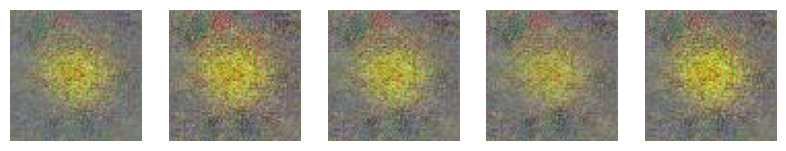

In [45]:
inference(testing_dataset)
visualize(random_idx)

Noise:
[[ 1.4758302   0.10208905 -0.32841668 ...  1.0210108  -0.9666184
  -0.23482022]
 [ 0.38059065 -1.3257059   1.0034839  ...  1.079231   -0.5721627
  -1.775215  ]
 [ 0.26191536 -0.6297633   1.6277099  ... -0.2337518   0.517809
   1.1073906 ]
 ...
 [ 0.4544312   0.529544   -0.59376955 ... -0.8784983   0.06554133
  -0.37248847]
 [-1.6568657   0.9892575   1.7557611  ...  1.1741315   0.08190037
  -0.68926245]
 [-0.65306664  0.11999224 -0.3223607  ...  0.5922454   0.69215685
   1.3782204 ]]
Time for inference is 1.1319 sec
this flower is white and purple in color with petals that are oval shaped 
this flower has several layers of upturned pink petals with pointed tips 
this flower is bright pink with overlapping petals and a lime green pistil 
the petals of this flower are tubular in nature and grow in bunches like grapes 
this flower has a long orange petal with yellow dots on it 


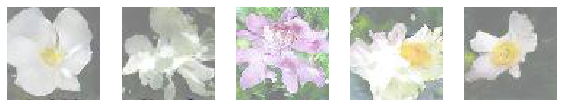

In [ ]:
inference(testing_dataset)

visualize(random_idx)

Noise:
[[-1.2725184  -0.9711118  -0.5393693  ... -0.26380852  0.10115943
   0.39391017]
 [ 1.1355842   0.6505292  -0.472464   ... -1.6744962   1.1382602
  -0.05837864]
 [-0.67060554  0.38606992 -0.25814685 ...  1.6933469  -0.6166498
   0.76080585]
 ...
 [-1.2363106   0.2243839  -0.34433877 ...  0.8438935   0.52368414
  -0.63039213]
 [-0.49114412  0.6352211  -1.4125369  ... -0.6259365  -1.4477416
   0.36768273]
 [-0.05199931  0.77441293  1.0219295  ... -0.19283983 -0.6897166
   0.09537832]]
Time for inference is 1.0928 sec
this flower is white and purple in color with petals that are oval shaped 
this flower has several layers of upturned pink petals with pointed tips 
this flower is bright pink with overlapping petals and a lime green pistil 
the petals of this flower are tubular in nature and grow in bunches like grapes 
this flower has a long orange petal with yellow dots on it 


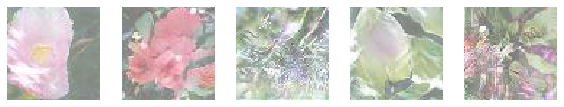

In [ ]:
inference(testing_dataset)
visualize(random_idx)

Noise:
[[ 2.6175692   0.5147658  -1.9151362  ...  0.38526377  0.05760048
   0.47151622]
 [-0.3533814   0.2894874  -1.8412292  ... -1.2098181   0.6306627
  -0.5056993 ]
 [-1.1462369  -0.18491061  0.29349625 ... -2.1832473   0.5805743
  -1.1608238 ]
 ...
 [-0.86325365  1.3974189   1.0503821  ... -0.24925816 -0.21674807
   1.1617973 ]
 [-0.67687124  0.83157176 -1.1484911  ...  0.12041593  0.26474714
  -0.24563836]
 [ 1.0829633   1.8881611  -1.5523912  ... -1.1464972  -0.59224737
  -2.1648674 ]]
Time for inference is 1.1529 sec
this flower is white and purple in color with petals that are oval shaped 
this flower has several layers of upturned pink petals with pointed tips 
this flower is bright pink with overlapping petals and a lime green pistil 
the petals of this flower are tubular in nature and grow in bunches like grapes 
this flower has a long orange petal with yellow dots on it 


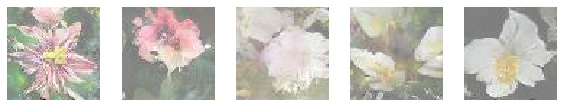

In [ ]:
inference(testing_dataset)
visualize(random_idx)